In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1=pd.read_csv(r"F:\Omkar_sir_files\CSV_Files\Visadataset (1).csv")
df1

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
cat=df1.select_dtypes(include='object').columns
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [4]:
num=df1.select_dtypes(exclude='object').columns
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [5]:
df1['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [6]:
df1['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [7]:
#i want how many ppl certified from asia
#i want how many ppl denied from asia

In [8]:
con1=df1['continent']=='Asia'
con2=df1['case_status']=='Certified'
con=con1 & con2
df1[con]

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
5,EZYV06,Asia,Master's,Y,N,2339,2012,South,78252.14,Year,Y,Certified
6,EZYV07,Asia,Bachelor's,N,N,4985,1994,South,53635.39,Year,Y,Certified
8,EZYV09,Asia,Bachelor's,N,N,4810,2012,Midwest,74362.19,Year,Y,Certified
10,EZYV11,Asia,Master's,N,N,2465,2004,Midwest,83588.56,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified


In [9]:
labels=df1['continent'].unique()
d1,d2=[],[]
for i in labels:
    con1=df1['continent']==i
    con2=df1['case_status']=='Certified'
    con3=df1['case_status']=='Denied'
    
    certi_con=con1&con2
    deni_con=con1&con3
    con=con1 & con2
    certified_count = len(df1[certi_con])
    denied_count = len(df1[deni_con])
    d1.append(certified_count)
    d2.append(denied_count)
data=zip(d1,d2)
an=pd.DataFrame(data,columns=['Certified','Denied'])
an


,Certified,Denied
0,11012,5849
1,397,154
2,2037,1255
3,2957,775
4,493,359
5,122,70


## **instead of numbers always show the insight using percentage**

In [11]:
col1=df1['continent']
col2=df1['case_status']
cross=pd.crosstab(col1,col2)
cross

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

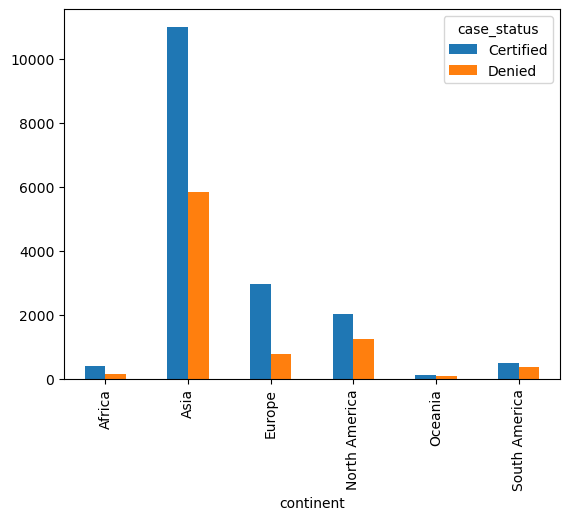

In [12]:
cross.plot(kind='bar')

In [13]:
col1=df1['continent']
col2=df1['case_status']
col3=df1['education_of_employee']
cols=[col2,col3]
a=pd.crosstab(col1,cols)
a

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

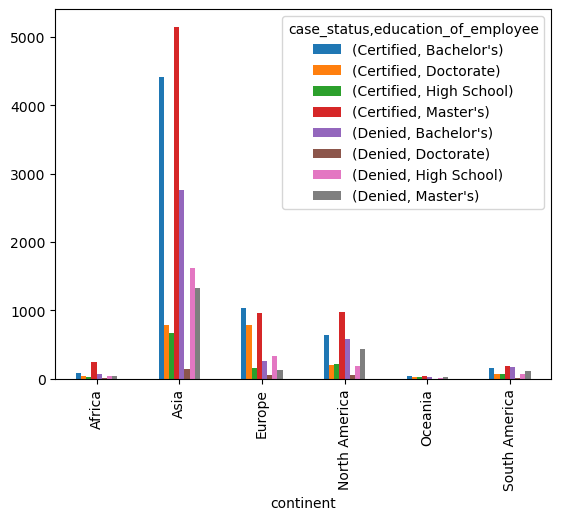

In [14]:
a.plot(kind='bar')

In [15]:
col1=df1['continent']
col2=df1['case_status']
col3=df1['education_of_employee']
cols=[col1,col2]
b=pd.crosstab(col3,cols)
b

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

<Axes: xlabel='education_of_employee'>

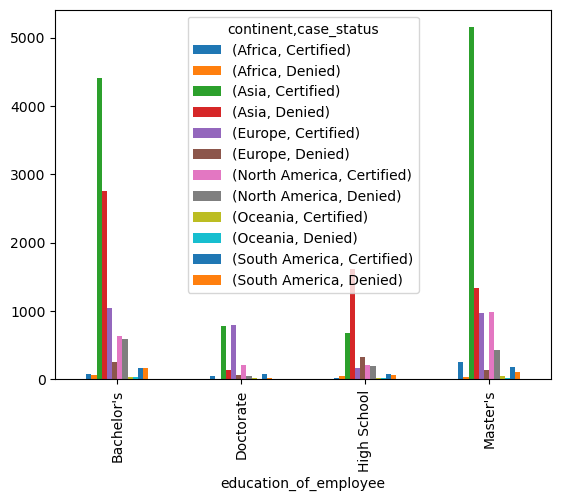

In [16]:
b.plot(kind='bar')

In [17]:
col1=df1['continent']
col2=df1['case_status']
col3=df1['education_of_employee']
cols=[col3,col2]
c=pd.crosstab(col1,cols)
c

education_of_employee Bachelor's        Doctorate        High School         \
case_status            Certified Denied Certified Denied   Certified Denied   
continent                                                                     
Africa                        81     62        43     11          23     43   
Asia                        4407   2761       780    143         676   1614   
Europe                      1040    259       788     58         162    328   
North America                641    584       207     51         210    191   
Oceania                       38     28        19      3          19     17   
South America                160    173        75     14          74     63   

education_of_employee  Master's         
case_status           Certified Denied  
continent                               
Africa                      250     38  
Asia                       5149   1331  
Europe                      967    130  
North America               979    429  
Oceania                      46     22  
South America               184    109

<Axes: xlabel='continent'>

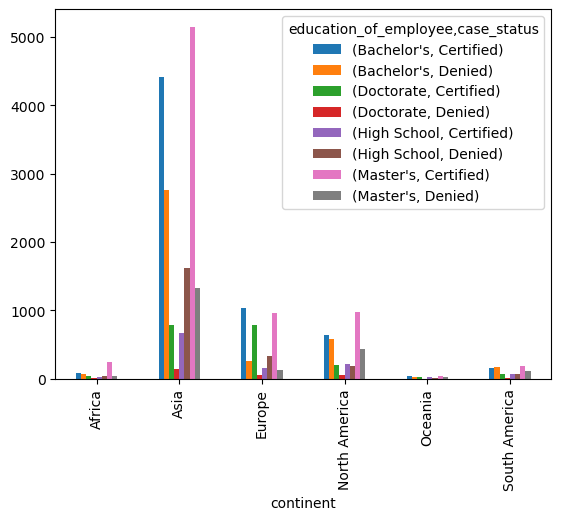

In [18]:
c.plot(kind='bar')

## **Scatter Plots**

- Scatter plots will give the realtaionship graph bet two numerical column
- how one vairiable is varying according another variable
- if we want get a value we need to do correlation

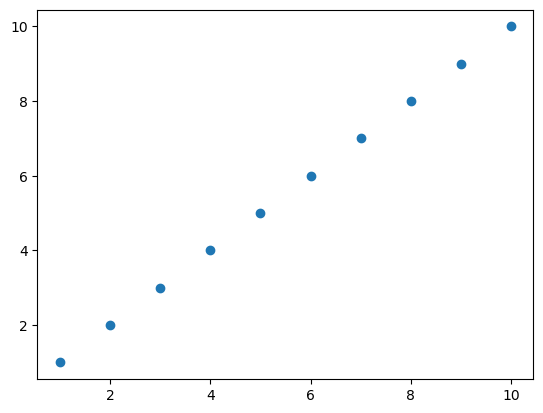

In [20]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.show()

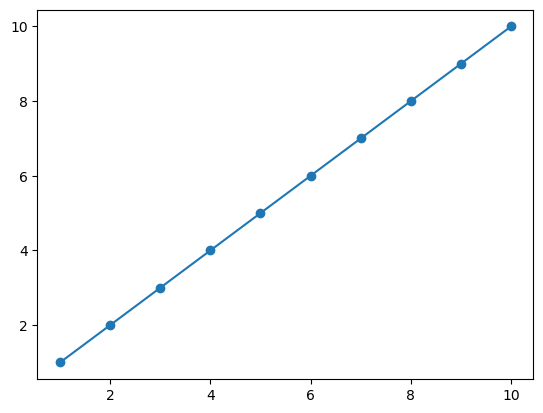

In [21]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

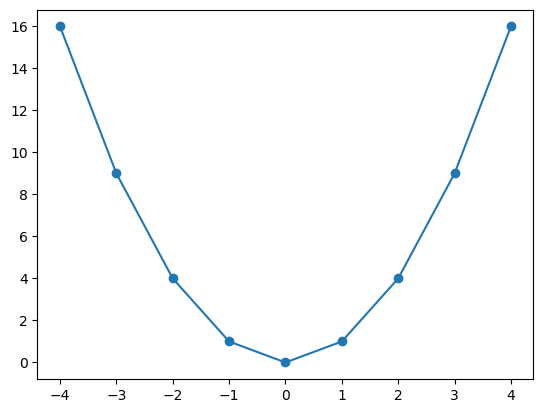

In [22]:
x=range(-4,5)
y=[i**2 for i in x]
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

In [23]:
num


Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

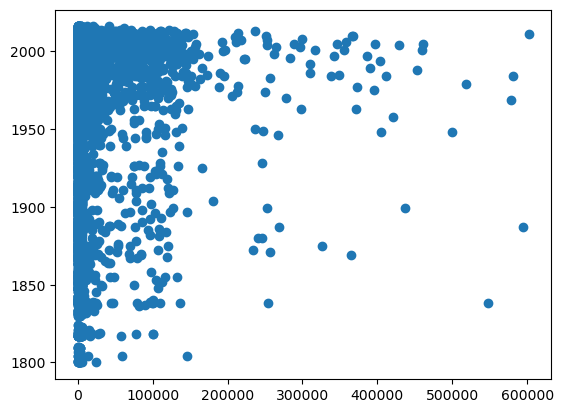

In [24]:
col1=df1['no_of_employees']
col2=df1['yr_of_estab']
plt.scatter(col1,col2)
plt.show()

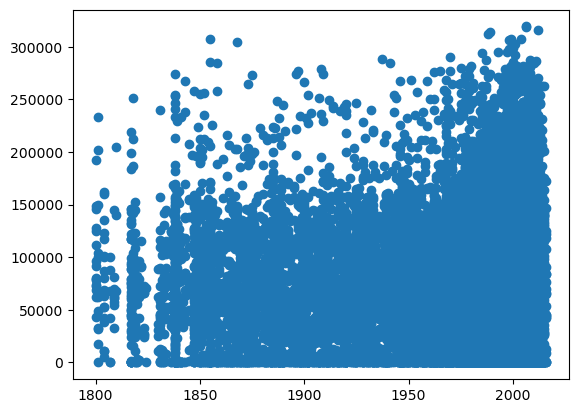

In [25]:
col1=df1['yr_of_estab']
col2=df1['prevailing_wage']
plt.scatter(col1,col2)
plt.show()

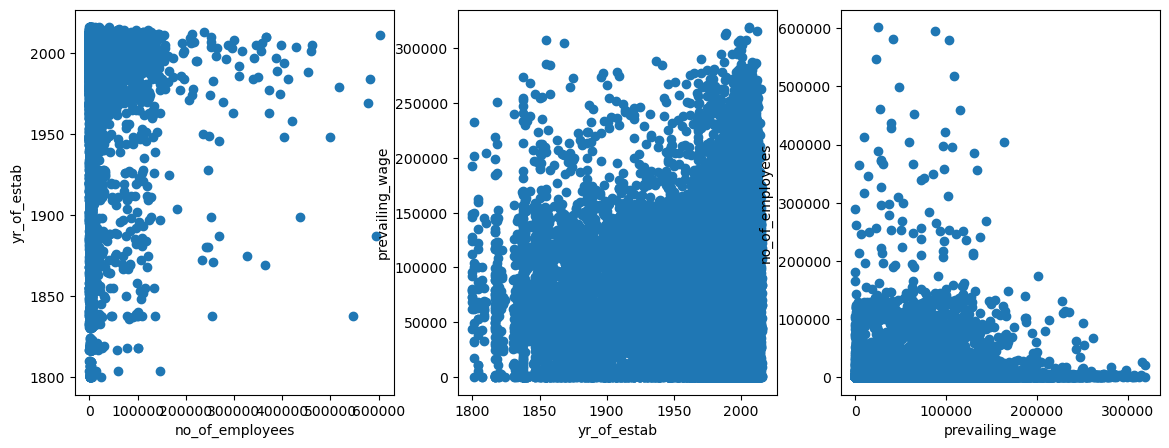

In [26]:
col1=df1['no_of_employees']
col2=df1['yr_of_estab']
col3=df1['prevailing_wage']
plt.figure(figsize=(14,5))
plt.subplot(1,3,1).scatter(col1,col2)
plt.xlabel('no_of_employees')
plt.ylabel('yr_of_estab')

plt.subplot(1,3,2).scatter(col2,col3)
plt.xlabel('yr_of_estab')
plt.ylabel('prevailing_wage')

plt.subplot(1,3,3).scatter(col3,col1)
plt.xlabel('prevailing_wage')
plt.ylabel('no_of_employees')

plt.show()

## **Correlation**

In [28]:
df1.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


## **Heat map**

<Axes: >

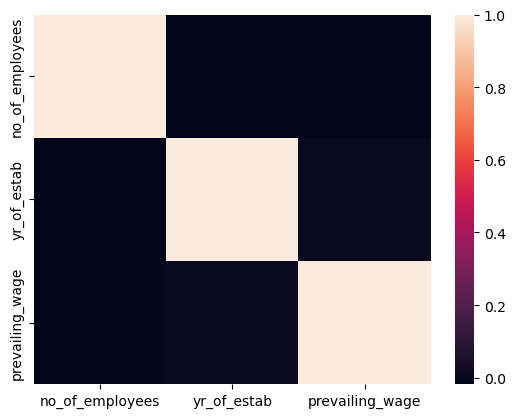

In [30]:
corr_visa=df1.corr(numeric_only=True)
sns.heatmap(corr_visa)

<Axes: >

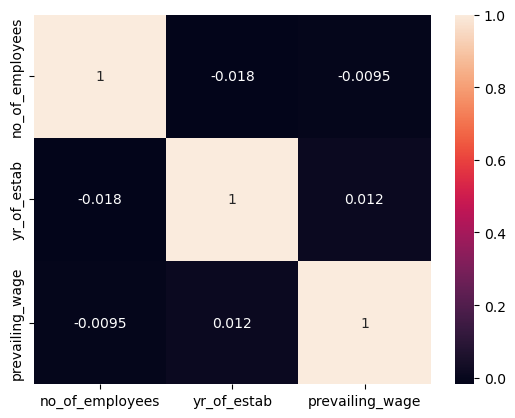

In [31]:
_visa=df1.corr(numeric_only=True)
sns.heatmap(corr_visa,annot=True)

In [32]:
wine_df=pd.read_csv(r"F:\Omkar_sir_files\CSV_Files\winequality_red.csv")
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<Axes: >

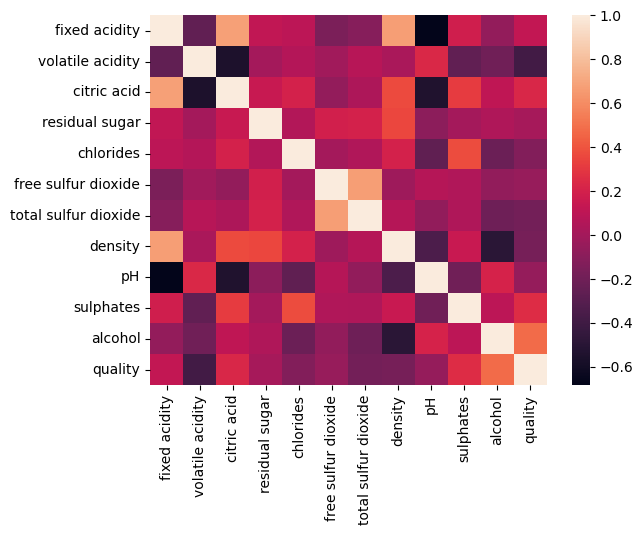

In [33]:
wine_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_corr)

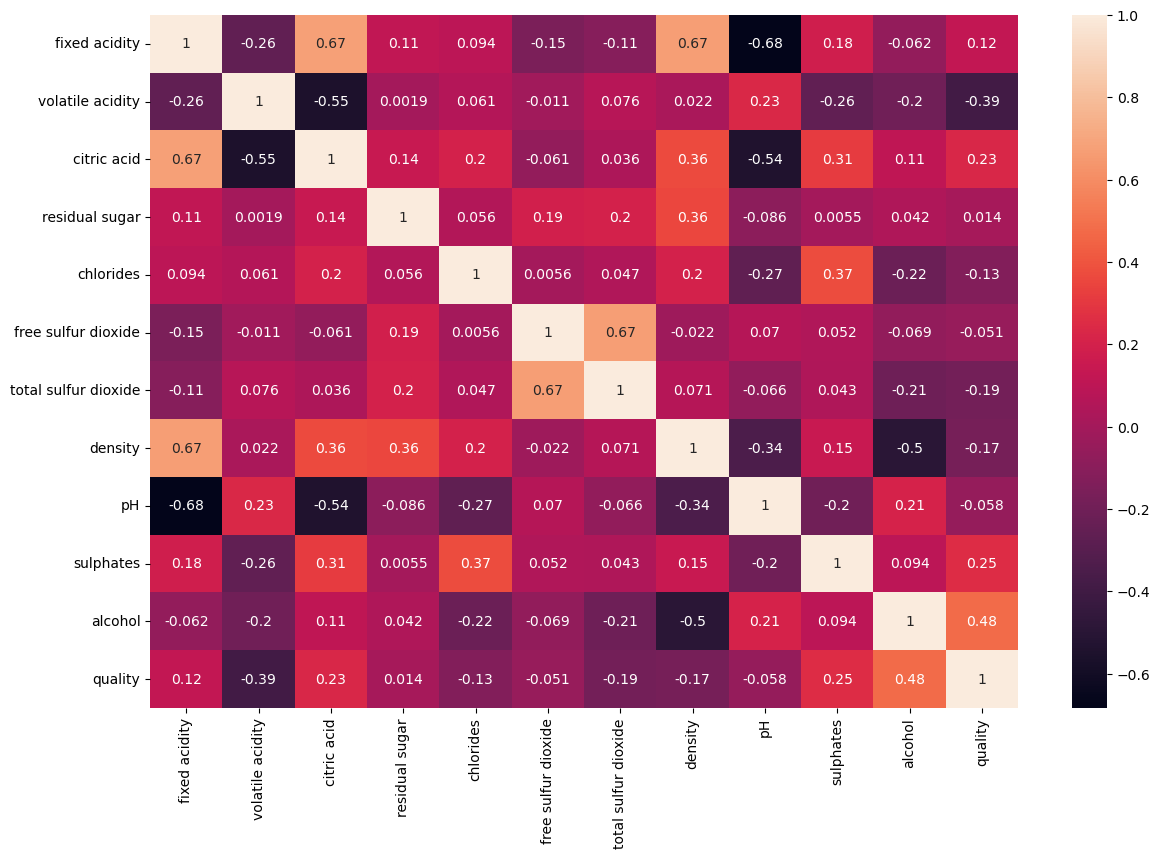

In [34]:
plt.figure(figsize=(14,9))
wine_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_corr,annot=True)
plt.show()

In [35]:
df1['continent','case_status']

KeyError: ('continent', 'case_status')

In [53]:
df1=pd.read_csv(r"F:\Omkar_sir_files\CSV_Files\Visadataset (1).csv")
df1

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [55]:
cat=df1.select_dtypes(include='object').columns
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [57]:
num=df1.select_dtypes(exclude='object').columns
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [58]:
df1[['continent','case_status']]

,continent,case_status
0,Asia,Denied
1,Asia,Certified
2,Asia,Denied
3,Asia,Denied
4,Africa,Certified
...,...,...
25475,Asia,Certified
25476,Asia,Certified
25477,Asia,Certified
25478,Asia,Certified


In [59]:
df1['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [60]:
con1=df1['continent']=='Asia'
con2=df1['case_status']=='Certified'
con=con1 & con2
len(df1[con])

11012

In [61]:
con1=df1['continent']=='Asia'
con2=df1['case_status']=='Certified'
con3=df1['case_status']=='Denied'
certi_con=con1 & con2
deni_con=con1 & con3
len(df1[certi_con]),len(df1[deni_con])


(11012, 5849)

In [62]:
labels=df1['continent'].unique()
d1,d2=[],[]
for i in labels:
    con1=df1['continent']==i
    con2=df1['case_status']=='Certified'
    con3=df1['case_status']=='Denied'
    
    certi_con=con1&con2
    deni_con=con1&con3
    con=con1 & con2
    certified_count = len(df1[certi_con])
    denied_count = len(df1[deni_con])
    d1.append(certified_count)
    d2.append(denied_count)
data=zip(d1,d2)
an=pd.DataFrame(data,index=labels,columns=['Certified','Denied'])
an


,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


## **crosstab**

In [64]:
id_col=df1['continent']
col=df1['case_status']
r1=pd.crosstab(id_col,col)
r1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

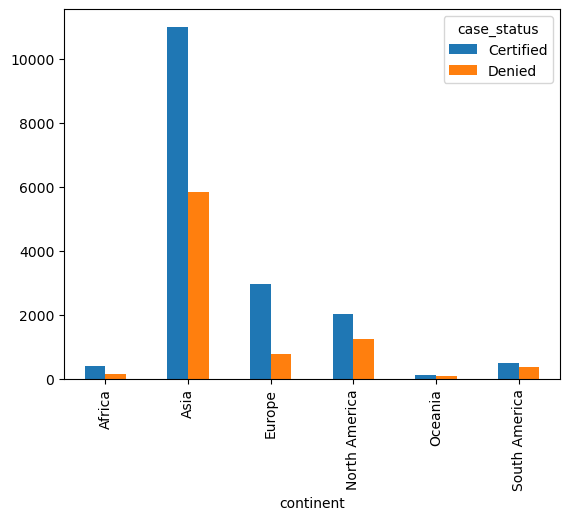

In [65]:
r1.plot(kind='bar')

In [66]:
col1=df1['continent']
col2=df1['case_status']
col3=df1['education_of_employee']
cols=[col2,col3]
a=pd.crosstab(col1,cols)
a

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

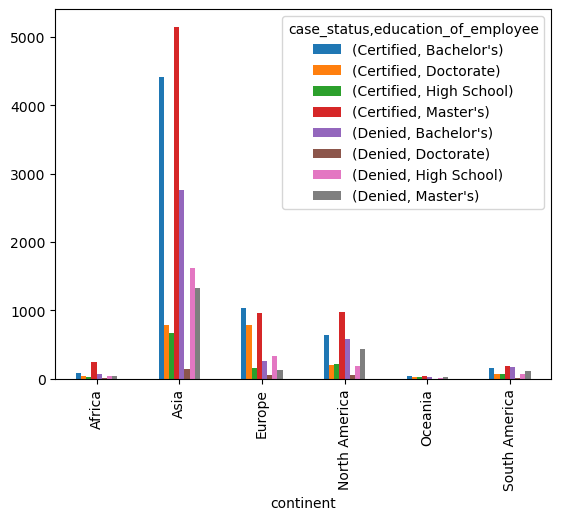

In [67]:
a.plot(kind='bar')

<Axes: xlabel='continent', ylabel='count'>

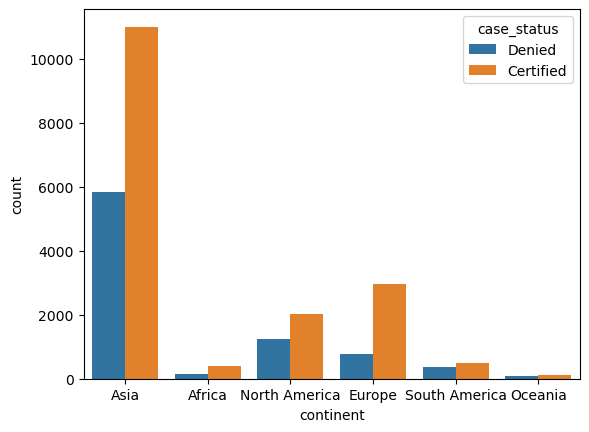

In [69]:
sns.countplot(data=df1,x='continent',hue='case_status')

<Axes: xlabel='continent', ylabel='count'>

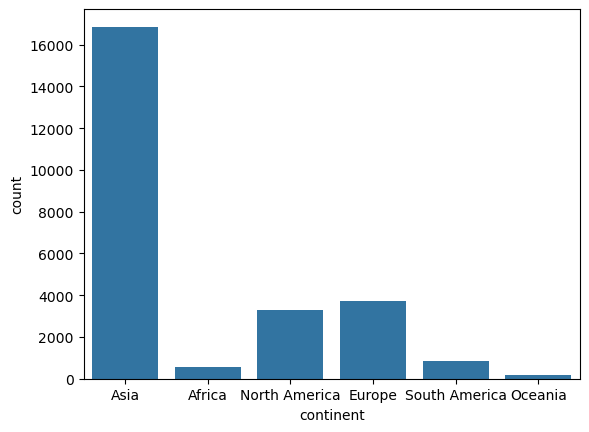

In [70]:
sns.countplot(data=df1,x='continent')

<Axes: xlabel='continent', ylabel='count'>

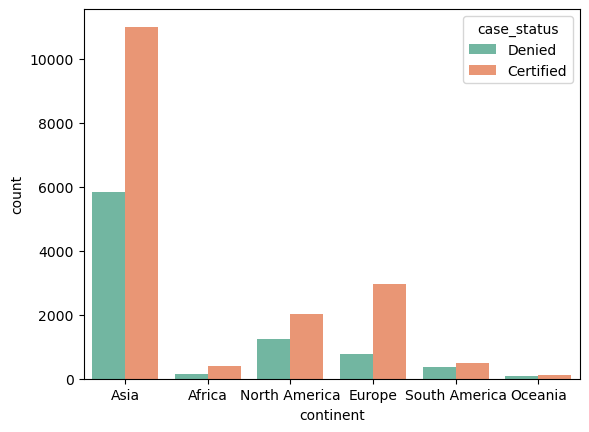

In [73]:
sns.countplot(data=df1,x='continent',hue='case_status',palette='Set2',width=0.8)

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [112]:
col1=df1['continent']
col2=df1['case_status']
col3=df1['education_of_employee']
cols=[col3,col2]
a=pd.crosstab(col1,cols)
a

education_of_employee Bachelor's        Doctorate        High School         \
case_status            Certified Denied Certified Denied   Certified Denied   
continent                                                                     
Africa                        81     62        43     11          23     43   
Asia                        4407   2761       780    143         676   1614   
Europe                      1040    259       788     58         162    328   
North America                641    584       207     51         210    191   
Oceania                       38     28        19      3          19     17   
South America                160    173        75     14          74     63   

education_of_employee  Master's         
case_status           Certified Denied  
continent                               
Africa                      250     38  
Asia                       5149   1331  
Europe                      967    130  
North America               979    429  
Oceania                      46     22  
South America               184    109

<Axes: xlabel='continent'>

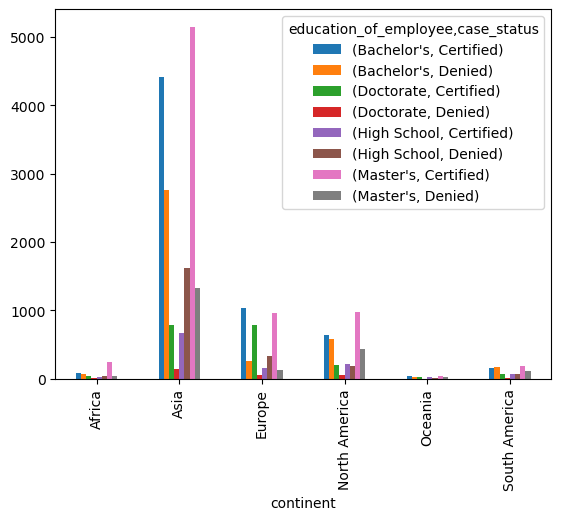

In [116]:
a.plot(kind='bar')

<Axes: xlabel='continent', ylabel='count'>

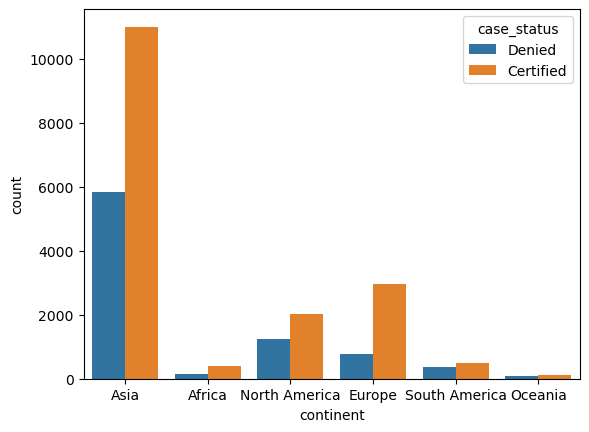

In [118]:
sns.countplot(data=df1,x='continent',hue='case_status')

## **Scatter Plots**

- bar chart : frequency table

- pie chart : relative frequency table

- histogram : frequency distribution plot

- box plot : Outlier analysis

- scatterplot: Relation between two numerical columns

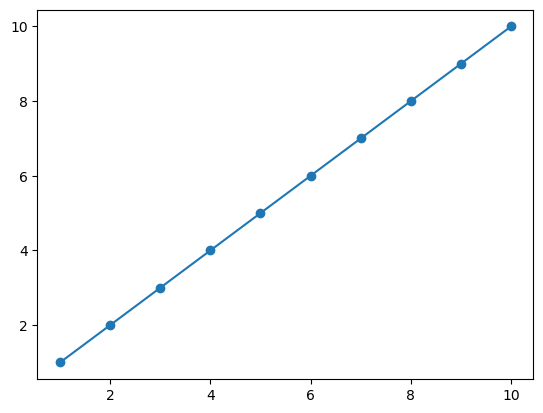

In [122]:
x=list(range(1,11))
y=list(range(1,11))
plt.scatter(x,y)
plt.plot(x,y)

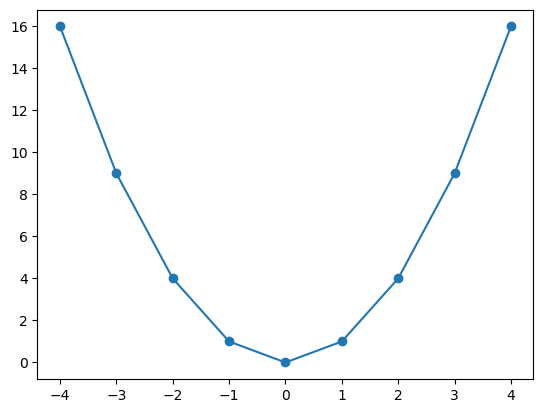

In [126]:
x=range(-4,5)
y=[i**2 for i in x]
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

Text(0.5, 1.0, 'no_of_employees and yr_of_estab')

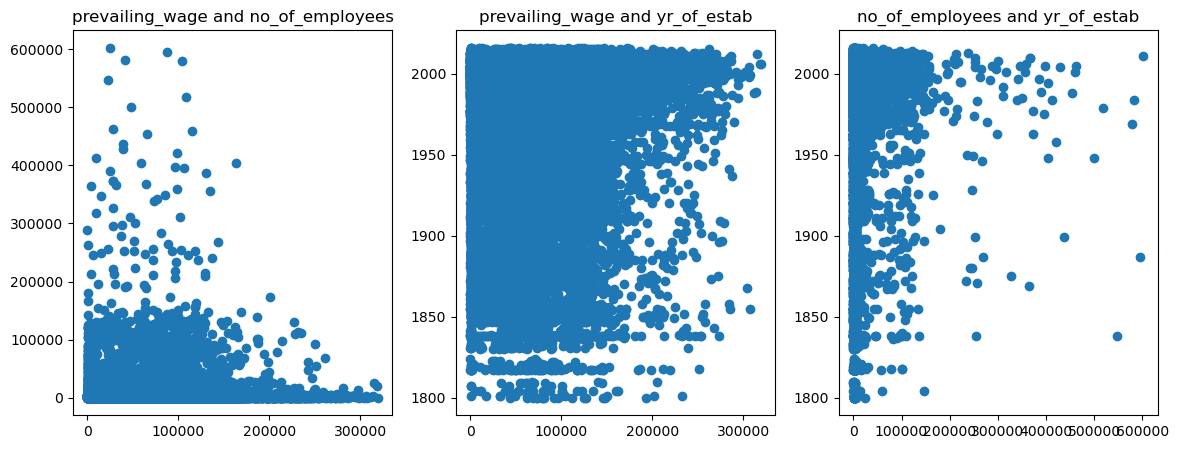

In [140]:
col1=df1['prevailing_wage']
col2=df1['no_of_employees']
col3=df1['yr_of_estab']
plt.figure(figsize=(14,5))
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('prevailing_wage and no_of_employees')
plt.subplot(1,3,2).scatter(col1,col3)
plt.title('prevailing_wage and yr_of_estab')
plt.subplot(1,3,3).scatter(col2,col3)
plt.title('no_of_employees and yr_of_estab')


## **Crrelation**

In [138]:
df1.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


## **Heamap**

<Axes: >

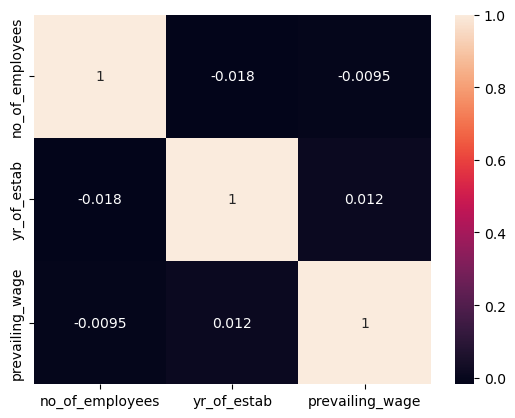

In [144]:
corr=df1.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

In [146]:
wine_df=pd.read_csv(r"F:\Omkar_sir_files\CSV_Files\winequality_red.csv")
wine_df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [150]:
wine_df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


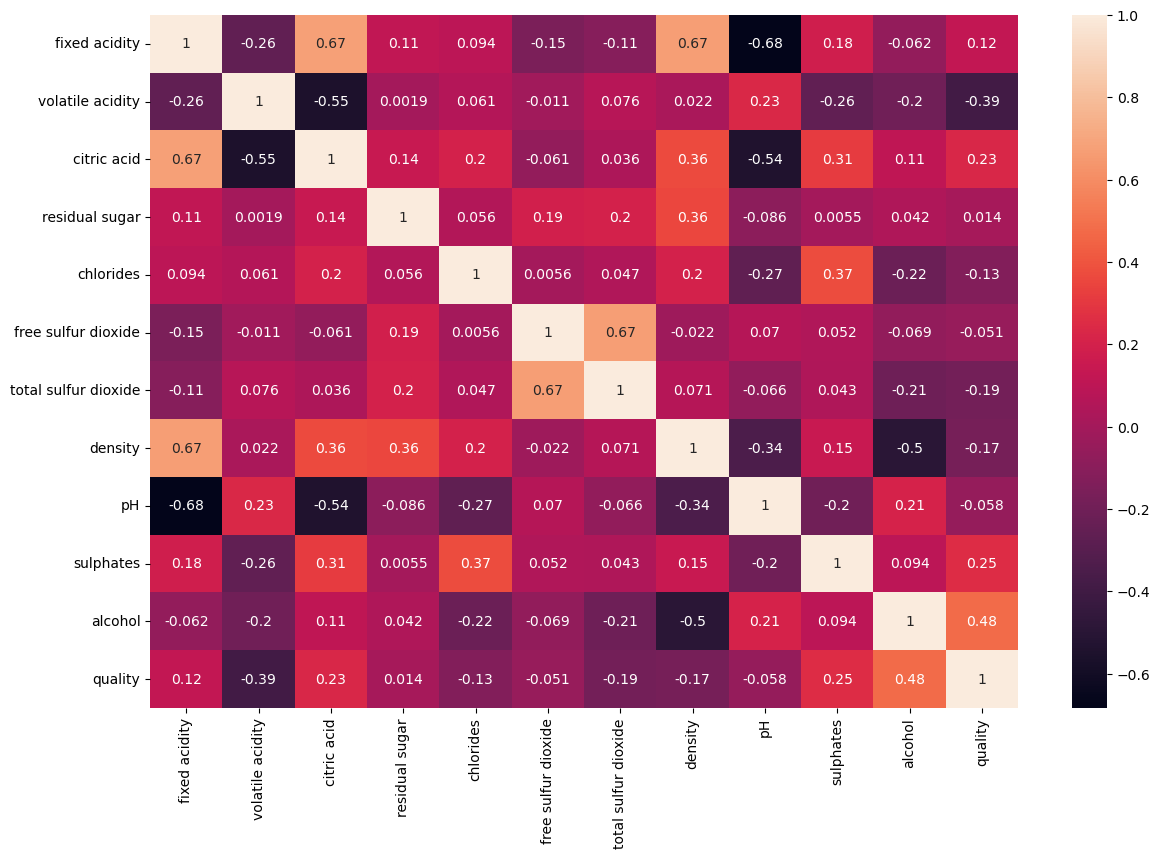

In [148]:
plt.figure(figsize=(14,9))
wine_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_corr,annot=True)
plt.show()

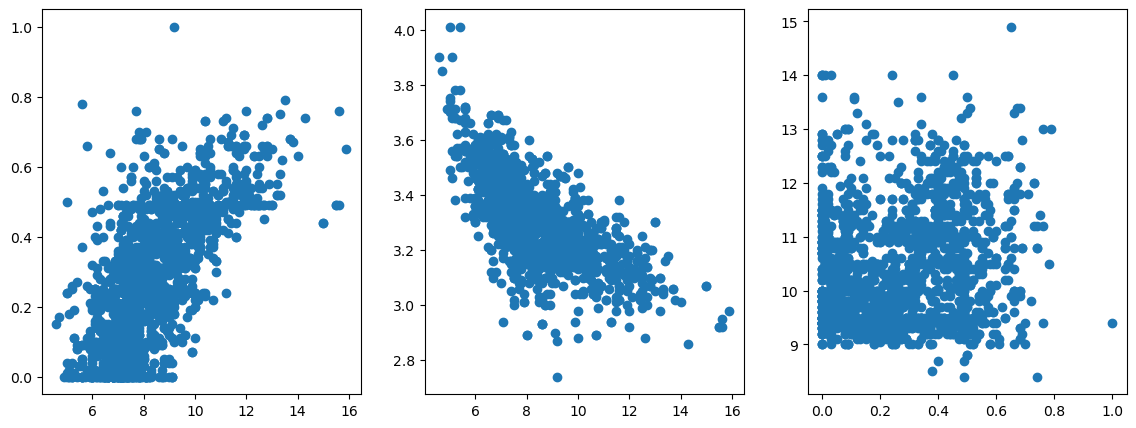

In [164]:
col1=wine_df['fixed acidity']
col3=wine_df['pH']
col2=wine_df['citric acid']
col4=wine_df['alcohol']
plt.figure(figsize=(14,5))
plt.subplot(1,3,1).scatter(col1,col2)
# plt.title('fixed acidity and pH')
plt.subplot(1,3,2).scatter(col1,col3)
# plt.title('fixed acidity and citric acid')
plt.subplot(1,3,3).scatter(col2,col4)
# plt.title('pH and alcohol')